In [1]:

#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

from multiprocessing import Pool, current_process
import threading
import queue
import time

sys.path.append("../python")
sys.path.append(".")
from canoe import def_species, load_configure
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
# from canoe.harp import radiation_band, radiation

def set_atmos_run_RT_concurrent(qNH3: float, 
                     T0: float = 180.0, 
                     RHmax: float=1.0,
                     adlnNH3dlnP: float=0.0,
                     pmin: float = 0.0, 
                     pmax: float = 0.0,
                     jindex: int = 0
                     ):  
    ## construct atmos with a rh limit
    ## jindex is the index of current processer, starting from zero, will add to mb.jst in canoe backend 
    mb.construct_atmosphere(pin, qNH3, T0, RHmax, jindex,"dry", 2500, 500)

    # Ts=mb.retrieve_Ts_given_T1bar(pin, qNH3, T0, RHmax, jindex,"dry", 2500, 500)

    ## construct moist atmosphere with bottom ts
    # mb.construct_atmosphere_Ts(pin, qNH3, Ts, RHmax, jindex,"dry", 2500)

    # modify the top humidity with a increment
    mb.modify_dlnNH3dlnP_rhmax(pin, adlnNH3dlnP, pmin, pmax, RHmax, jindex) 

    ## do radiative transfer
    rad.cal_radiance(mb, mb.k_st, mb.j_st+jindex)
    tb = np.array([0.0] * 4 * nb)
    print(tb.shape)
    for ib in range(nb):

        toa = rad.get_band(ib).get_toa()[0]
        tb[ib * 4 : ib * 4 + 4] = toa
    return tb

def rtm_dry_adiabatic(xNH3, theta, RHmax, ad, pmax,pmin):
    ## calculate 6chanel radiances 
    tb=set_atmos_run_RT_concurrent(xNH3, # NH3.ppmv
                     theta,       # Temperature
                     RHmax,         # RH_max_NH3
                     ad,        # adlnNH3/dlnP
                     pmin,         # pmin [Pa]
                     pmax,          # pmax [Pa]
                     0)
    return tb[::4], (tb[::4]-tb[3::4])/(tb[::4])*100

nx2 = 5  ## shall not be less than N_walkers, can be a little greater for safty.

## initialize Canoe
global pin
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")

vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

config = load_configure("juno_mwr.yaml")
# print(pin.get_real("problem", "qH2O.ppmv"))

pin.set_boolean("job","verbose", False)

print(pin.get_string("mesh","nx2"))
pin.set_string("mesh","nx2", f"{nx2}")

print(pin.get_string("mesh","nx2"))

mesh = Mesh(pin)
mesh.initialize(pin)

global mb, rad, nb
mb = mesh.meshblock(0)
rad = mb.get_rad()
nb = rad.get_num_bands()
print(f"nb={nb}")
# Create a grid for reflectance at band 3 and band 6
ADs= [-0.12,-0.1,-0.08,-0.06,-0.04,-0.02,0] 
Thetas  = [160,165,170,175,180,185,190]

# Initialize arrays for TBs and LDs with the same dimensions
TBs = np.zeros((len(ADs), len(Thetas),6), dtype=np.float32)  # Radiances array
LDs = np.zeros((len(ADs), len(Thetas),6), dtype=np.float32)  # Lookup table array

RHmax=0.71
xnh3=362
# theta=176
pmin=1E-3

Thetas  = [160,165,170,175,180,185,190]

for ix, ad in enumerate(ADs):
    for it, theta in enumerate(Thetas):
        print(ad,theta)
        TBs[ix,it,:], LDs[ix,it,:] =rtm_dry_adiabatic(xnh3, theta, RHmax, ad, 5*1E5,pmin)
        
with h5py.File('model_LUT_TB_LD_dry_gradient.h5', 'w') as f:
    f.create_dataset('TBs', data=TBs)
    f.create_dataset('LDs', data=LDs)





5Log, "2026-03-07 21:07:49",        canoe, 1., "Installing monitor canoe"
Log, "2026-03-07 21:07:49",        canoe, 1.1., "Initialize IndexMap"

5
Log, "2026-03-07 21:07:49",         snap, 3., "Installing monitor snap"
Log, "2026-03-07 21:07:49",         snap, 3.1., "Initialize Thermodynamics"
Log, "2026-03-07 21:07:49",         snap, 3.1.1., "Enrolling vapor functions"
Log, "2026-03-07 21:07:49",         snap, 3.1.1.1., "Enrolling H2O vapor pressures"
Log, "2026-03-07 21:07:49",         snap, 3.1.2.1., "Enrolling NH3 vapor pressures"
Log, "2026-03-07 21:07:49",         snap, 4.1., "Initialize Decomposition"
Log, "2026-03-07 21:07:49",         snap, 5.1., "Initialize ImplicitSolver"
Log, "2026-03-07 21:07:49", microphysics, 7., "Installing monitor microphysics"
Log, "2026-03-07 21:07:49", microphysics, 7.1., "Initialize Microphysics"
Log, "2026-03-07 21:07:49",         harp, 9., "Installing monitor harp"
Log, "2026-03-07 21:07:49",         harp, 9.1., "Initialize Radiation"
Log, "2026-

In [4]:
xNH3s= [-0.12,-0.1,-0.08,-0.06,-0.04,-0.02,0] 
# Thetas  = [0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6]

Thetas  = [160,165,170,175,180,185,190]

import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

mwr_coeff = "../../../mwr_polar_coefficients.csv"
df = pd.read_csv(mwr_coeff, header=None, names=["channel", "c0", "c1", "c2"])
obs = df["c0"].values
obsLD=[13.2, 10.0, 6.9, 5.9, 4.5, 1.4]  

print("obsTB:", obs)
print("obsLD:", obsLD)

obsTB: [908.46972469 479.08699872 338.75165919 251.70653583 192.47340754
 141.07444985]
obsLD: [13.2, 10.0, 6.9, 5.9, 4.5, 1.4]


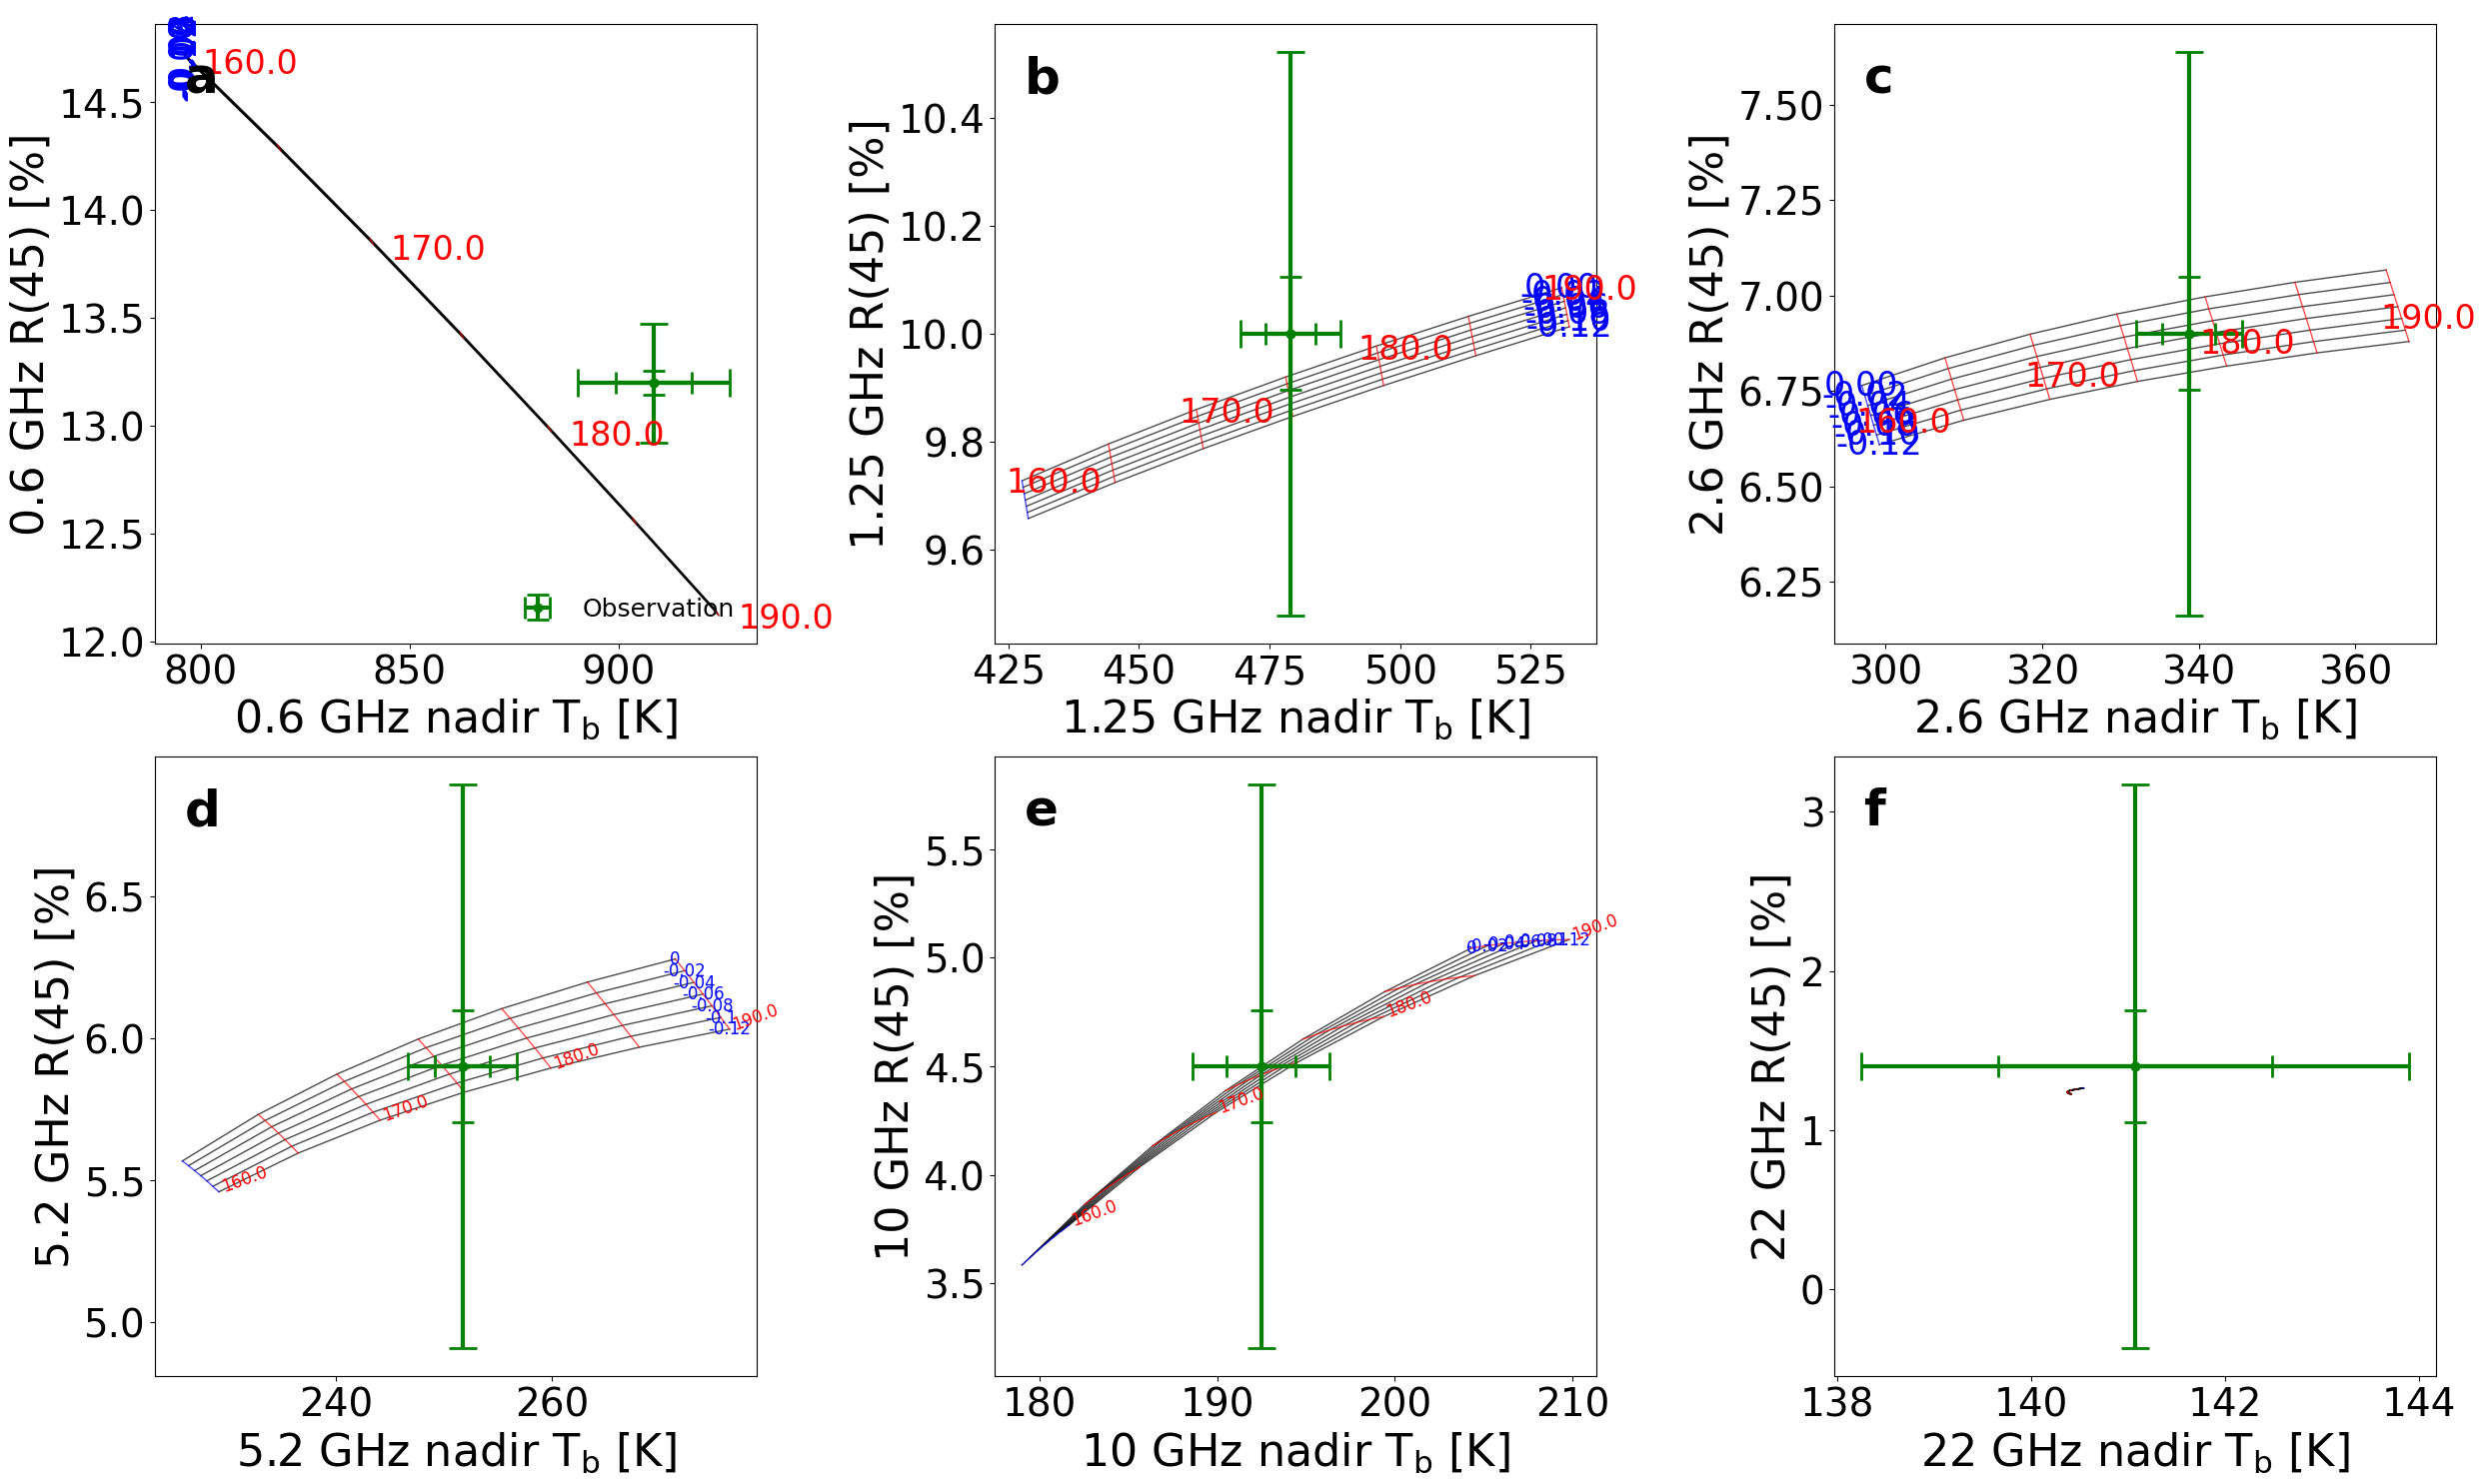

In [5]:
#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm
from scipy.stats import multivariate_normal
import seaborn as sns
from scipy.stats import gaussian_kde


with h5py.File("model_LUT_TB_LD_dry_gradient.h5","r") as f:
    TBs=f["TBs"][:]
    LDs=f["LDs"][:]

# xNH3s= [-0.12,-0.1,-0.08,-0.06,-0.04,-0.02,0] 
# Thetas  = [0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6]

# Plot the cloud optical depth as contour lines
ich=1

fig, axes = plt.subplots(2, 3, figsize=(25,15))  # 2 rows, 3 columns, with a custom figure size

fontsize=24
axs=axes.flatten()





for iax, ax in enumerate(axs):
    ich=iax
    # if ich<3 or ich==5:
    #     continue
    for ix, xnh3 in enumerate(xNH3s):
        if ix==0:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="k",alpha=0.7, linewidth=1)
        else:
            ax.plot(TBs[ix,:,ich], LDs[ix,:,ich],color="k",alpha=0.7, linewidth=1)
    
        if ich==0:
            ax.text(TBs[ix, 0,ich], LDs[ix, 0,ich], f"{xnh3:4.2f}", color="blue", rotation=90, fontsize=fontsize, va="center",ha="center")
        elif ich==1:
            ax.text(TBs[ix, -1,ich], LDs[ix, -1,ich], f"{xnh3:4.2f}", color="blue", fontsize=fontsize, va="center",ha="center")
        elif ich==2:
            ax.text(TBs[ix, 0,ich], LDs[ix, 0,ich], f"{xnh3:4.2f}", color="blue",  rotation=0, fontsize=fontsize, va="center",ha="center")
        elif ich==3:
            ax.text(TBs[ix, -1,ich], LDs[ix, -1,ich], f"{xnh3}", color="blue", rotation=0, fontsize=12, va="center",ha="center")
        elif ich==4:
            ax.text(TBs[ix, -1,ich], LDs[ix, -1,ich], f"{xnh3}", color="blue", rotation=0, fontsize=12, va="center",ha="center")
    # ax.text(TBs[-3, -1,ich], LDs[3, -1,ich], "xNH3", color="Blue",fontsize=12)

    for it, theta in enumerate(Thetas):
        if it==0:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="b",alpha=0.7, linewidth=1)
        else:
            ax.plot(TBs[:,it,ich], LDs[:,it,ich],color="r",alpha=0.7, linewidth=1)
        if it%2==0:
            if ich==0:
                ax.text(TBs[0,it,ich]*1.005, LDs[0,it,ich]*0.995, f"{theta:3.1f}", color="red", fontsize=fontsize)
            elif ich==1:
                ax.text(TBs[0,it,ich]*0.99, LDs[0,it,ich]*1.005, f"{theta:3.1f}", color="red", fontsize=fontsize)
            elif ich==2:
                ax.text(TBs[0,it,ich]*0.99, LDs[0,it,ich]*1.005, f"{theta:3.1f}", color="red", fontsize=fontsize)
            elif ich==3:
                ax.text(TBs[0,it,ich], LDs[0,it,ich], f"{theta:3.1f}", color="red", rotation=20, fontsize=12)
            elif ich==4:
                ax.text(TBs[0,it,ich], LDs[0,it,ich], f"{theta:3.1f}", color="red", rotation=20, fontsize=12)




for iax, ax in enumerate(axs):
    ich=iax
    LD= obsLD[ich]
    ax.errorbar(obs[ich],LD, xerr=0.01*obs[ich], yerr=0.5/obs[ich]*100., fmt='o', linewidth=3,capsize=8, capthick=2, label="Observation", color='green')
    ax.errorbar(obs[ich],LD, xerr=0.02*obs[ich], yerr=2.5/obs[ich]*100., fmt='o', linewidth=3,capsize=10,capthick=2, color='green')

    # Add labels and title
    GHz=[0.6,1.25, 2.6, 5.2, 10, 22]
    ax.set_xlabel(fr'{GHz[ich]} GHz nadir T$_\text{{b}}$ [K]', fontsize=32)
    ax.set_ylabel(fr'{GHz[ich]} GHz R(45) [%]', fontsize=32)
    # ax.set_title(f'Channel {ich+1}')

    ax.tick_params(axis='x', labelsize=28)  # Change 14 to any desired font size
    ax.tick_params(axis='y', labelsize=28)  # Change 14 to any desired font size

    ax.text(0.05, 0.95, chr(97+iax), transform=ax.transAxes, fontsize=36, fontweight='bold', va='top', ha='left')




# axs[0].set_xlim(680, 1050)
# axs[0].set_ylim(9, 16.8)

# axs[1].set_xlim(370, 610)
# axs[1].set_ylim(9.8, 10.2)

# axs[2].set_xlim(256, 395)
# axs[2].set_ylim(6.4, 7.5)

# axs[2].set_xlim(198, 290)
# axs[2].set_xlim(245, 260)
# axs[2].set_ylim(5.6, 6.2)

# axs[3].set_xlim(165, 215)
# axs[3].set_xlim(190, 197)
# axs[3].set_ylim(5.75, 6.15)
# axs[4].set_ylim(4.3, 4.8)
# axs[5].set_ylim(0, 3)

# axs[0].set_yticks([9,10,11,12])
# axs[1].set_yticks([6.2,6.6,7.0,7.4,7.8])
# axs[3].set_yticks([5,5.5,6,6.5])




axs[0].legend(fontsize=18, frameon=False, ncol=2, loc='lower right')

plt.tight_layout()

plt.show()
